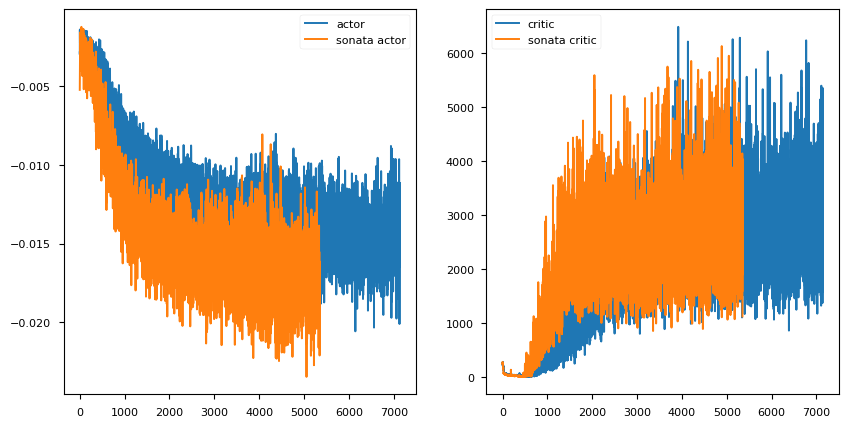

In [241]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-paper')  # 更改图表风格

sonata_id=5
loss= np.load('results_rl/avg_loss150.npy')
sonata_loss= np.load('results_rl/avg_loss_sonata'+str(sonata_id)+'.npy')
kgt_loss=np.load('results_kgt/avg_loss_kgt_0.npy')
cen_loss=np.load('../trained/avg_loss.npy')
dsgt_loss=np.load('results_dsgt/avg_loss_dsgt_2.npy')
ct=np.arange(0,cen_loss.shape[0])
# times1 = np.load('results_rl/timesteps_dinno_50.npy')
# times1
loss.shape
fig,ax=plt.subplots(1,2,figsize=(10,5))
t=np.arange(0,loss.shape[0])
st=np.arange(0,sonata_loss.shape[0])
ax[0].plot(t,loss[:,0],label='actor',zorder=1)
ax[0].plot(st,sonata_loss[:,0],label='sonata actor',zorder=4)
# ax[0].plot(ct,cen_loss[:,0],label='centralized actor',zorder=3)
# ax[0].plot(kgt_loss[:,0],label='kgt actor',zorder=2)
# ax[0].plot(dsgt_loss[:,0],label='dsgt actor',zorder=2)
#limit y axis to 0.005max
# ax[0].set_ylim([-0.02,0.01])
ax[1].plot(t,loss[:,1],label='critic')
ax[1].plot(st,sonata_loss[:,1],label='sonata critic')
# ax[1].plot(ct,cen_loss[:,1],label='centralized critic')
# ax[1].plot(kgt_loss[:,1],label='kgt critic')
# ax[1].plot(dsgt_loss[:,1],label='dsgt critic')
ax[0].legend()
ax[1].legend()
plt.show()

In [3]:
dsgt_id=0
dsgt_dir='results_dsgt'
# dsgt_dir='trained'

reward_kgt1=np.load(f"trained/avg_ep_rews_kgt_4.npy")
kts=np.load(f"trained/timesteps_kgt_4.npy")
reward_gt1=np.load(f"{dsgt_dir}/avg_ep_rews_dsgt_"+str(dsgt_id)+".npy")
ts=np.load(f"{dsgt_dir}/timesteps_dsgt_"+str(dsgt_id)+".npy")
plt.plot(ts,reward_gt1)
plt.plot(kts,reward_kgt1)
plt.legend(['dsgt','kgt'])

FileNotFoundError: [Errno 2] No such file or directory: 'trained/avg_ep_rews_kgt_4.npy'

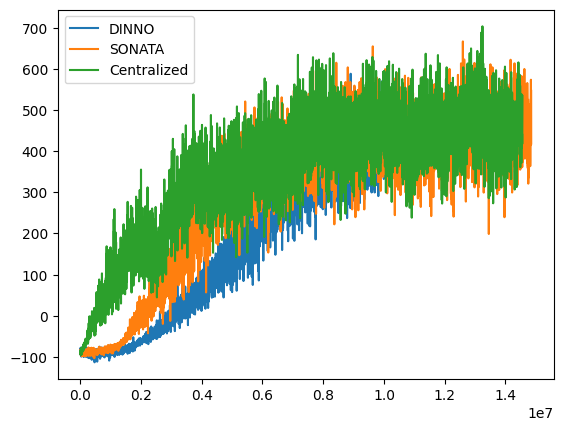

In [4]:
from matplotlib.ticker import FuncFormatter
sonata_id=666
dinno_id=666
times2=np.load('results_sonata/timesteps_sonata_'+str(sonata_id)+'.npy')
rewards2=np.load('results_sonata/avg_ep_rews_sonata_'+str(sonata_id)+'.npy')
# rewards1 = np.load('results_rl/avg_ep_rews_dinno_'+str(dinno_id)+'.npy')
rewards1=np.load("trained/avg_ep_rews_cadmm_0.npy")
times1=np.load("trained/timesteps_cadmm_0.npy")
reward_gt1=np.load("trained/avg_ep_rews_dsgt_1.npy")
plt.plot(times1,rewards1,label='DINNO')
plt.plot(times2,rewards2,label='SONATA')
# plt.plot(times2, reward_gt1, label="DSGT")
# Load Centralized
times_cent = np.load('../trained/timesteps.npy')
reward_cent=np.load('../trained/avg_ep_rews.npy')

plt.plot(times_cent, reward_cent, label="Centralized")
plt.legend()
# 设置x轴的坐标单位为1e7
# formatter = FuncFormatter(lambda x, pos: f'{x / 1e7:.1f}')
# plt.gca().xaxis.set_major_formatter(formatter)
# plt.savefig('sonata_const_lr.png')

In [242]:
import math


def smooth(scalars, weight=0.1) :
    """
    EMA implementation according to
    https://github.com/tensorflow/tensorboard/blob/34877f15153e1a2087316b9952c931807a122aa7/tensorboard/components/vz_line_chart2/line-chart.ts#L699
    """
    last = 0
    smoothed = np.zeros_like(scalars)
    num_acc = 0
    for next_val in scalars:
        last = last * weight + (1 - weight) * next_val
        num_acc += 1
        # de-bias
        debias_weight = 1
        if weight != 1:
            debias_weight = 1 - math.pow(weight, num_acc)
        smoothed_val = last / debias_weight
        smoothed[num_acc-1] = smoothed_val

    return smoothed

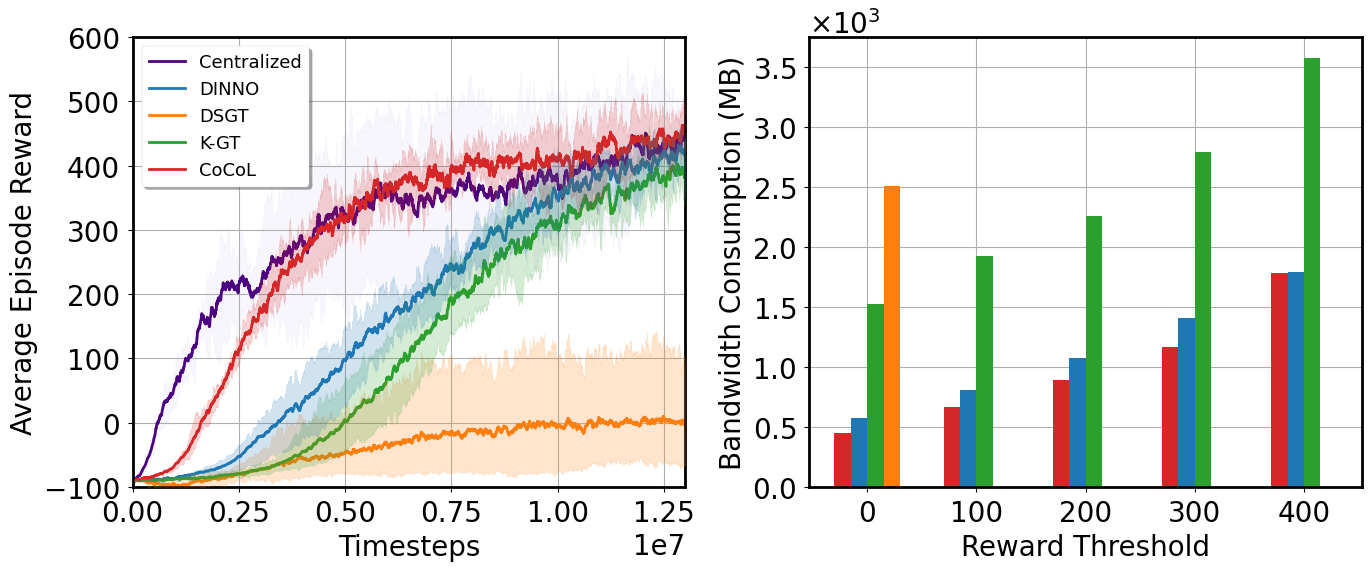

In [255]:
plt.rcParams.update({'font.size': 16})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
def smooth_funciton(data,windows_size=20):
    if windows_size==0:
        return data
    else:
        return np.convolve(data, np.ones(windows_size)/windows_size, mode='valid')
sonata_list=[]
dinno_list=[]
cen_list=[]
dsgt_list=[]
kgt_list=[]
window_size=20
(fig, axs) = plt.subplots(1,2,figsize=(14, 6), tight_layout=True)
ax0=axs[0]
plt.style.use('seaborn-paper')  # 更改图表风格
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
time_stamp_dis=smooth_funciton(np.load('results_sonata/timesteps_sonata_0.npy'),windows_size=window_size)
time_stamp_dinno=smooth_funciton(np.load('results_dinno/timesteps_dinno_1.npy'),windows_size=window_size)
time_stamp_kgt=smooth_funciton(np.load('results_kgt/timesteps_kgt_0.npy'),windows_size=window_size)
time_stamp_dsgt=smooth_funciton(np.load('results_dsgt/timesteps_dsgt_0.npy'),windows_size=window_size)
time_stamp_cen=smooth_funciton(np.load('../results_cen/timesteps_0.npy'),windows_size=window_size)
for i in range(5):
    cen_reward=np.load('../results_cen/avg_ep_rews_'+str(i)+'.npy')
    cen_list.append(smooth_funciton(cen_reward,windows_size=window_size))
    sonata_reward=np.load('results_sonata/avg_ep_rews_sonata_'+str(i)+'.npy')
    sonata_list.append(smooth_funciton(sonata_reward,windows_size=window_size))
    dinno_reward=np.load('results_dinno/avg_ep_rews_dinno_'+str(i)+'.npy')
    dinno_list.append(smooth_funciton(dinno_reward,windows_size=window_size))
    if i in range(1,5):
        dsgt_reward=np.load('results_dsgt/avg_ep_rews_dsgt_'+str(i)+'.npy')
        # print(f'{i} dsgt shape {dsgt_reward.shape}')
        dsgt_list.append(smooth_funciton(dsgt_reward,windows_size=window_size))
    # if i in range(1,4):
    kgt_reward=np.load('results_kgt/avg_ep_rews_kgt_'+str(i)+'.npy')
    kgt_list.append(smooth_funciton(kgt_reward,windows_size=window_size))

# for i in [8,9]:
    
#     dinno_reward=np.load('results_dinno/avg_ep_rews_dinno_'+str(i)+'.npy')
#     dinno_list.append(smooth_funciton(dinno_reward,windows_size=window_size))
sonata_list=np.stack(sonata_list)

dinno_list=np.stack(dinno_list[1:])
# dinno_list=np.stack(dinno_list)

cen_list=np.stack(cen_list)
dsgt_list=np.stack(dsgt_list)
kgt_list=np.stack(kgt_list)
clip=10000
ax0.plot(time_stamp_cen,smooth(np.mean(cen_list,axis=0)),label='Centralized',c='indigo',linewidth=2)
ax0.plot(time_stamp_dinno*1.2,smooth(np.mean(dinno_list,axis=0)),label='DINNO',c=default_colors[0],linewidth=2)
ax0.plot(time_stamp_dsgt,smooth(np.mean(dsgt_list,axis=0)),label='DSGT',c=default_colors[1],linewidth=2)
ax0.plot(time_stamp_kgt,smooth(np.mean(kgt_list,axis=0)),label='K-GT',c=default_colors[2],linewidth=2)
ax0.plot(time_stamp_dis[:clip]/1.1,smooth(np.mean(sonata_list,axis=0))[:clip],label='CoCoL',c=default_colors[3],linewidth=2)
alpha_value=0.2
ax0.fill_between(time_stamp_dinno[:clip]*1.2,smooth(np.amin(dinno_list,axis=0))[:clip],smooth(np.amax(dinno_list,axis=0))[:clip],alpha=alpha_value,color=default_colors[0],zorder=6)
ax0.fill_between(time_stamp_cen,smooth(np.amin(cen_list,axis=0)),smooth(np.amax(cen_list,axis=0)),alpha=0.05,color='slateblue',zorder=1)
ax0.fill_between(time_stamp_dsgt,smooth(np.amin(dsgt_list,axis=0)),smooth(np.amax(dsgt_list,axis=0)),alpha=alpha_value,color=default_colors[1],zorder=3)
ax0.fill_between(time_stamp_kgt,smooth(np.amin(kgt_list,axis=0)),smooth(np.amax(kgt_list,axis=0)),alpha=alpha_value,color=default_colors[2],zorder=4)
ax0.fill_between(time_stamp_dis[:clip]/1.1,smooth(np.amin(sonata_list,axis=0))[:clip],smooth(np.amax(sonata_list,axis=0))[:clip],alpha=alpha_value,color=default_colors[3],zorder=5)

ax0.legend(loc='upper left',fontsize=13,shadow=True,frameon=True)
ax0.tick_params(axis='both', which='major', labelsize=20)

ax0.set_xlim([0, 1.3e7])
ax0.set_ylim([-100, 600])
ax0.set_xlabel('Timesteps',fontsize=20)
ax0.set_ylabel('Average Episode Reward',fontsize=20)
ax0.xaxis.get_offset_text().set_fontsize(20)
# 设置边框加粗
for spine in ax0.spines.values():
    spine.set_linewidth(2)  # 你可以根据需要调整这个值
ax0.grid()

ax1=axs[1]
model_size=0.14332962
edge=3
reward_list=np.array([0,100,200,300,400])
sonata_reward_list=[]
dinno_reward_list=[]
kgt_reward_list=[]
dsgt_reward_list=[]
for val in reward_list:
    sonata_reward=np.argmax(sonata_list>val,axis=1)*model_size*edge*2/1.2
    sonata_reward_list.append(np.mean(sonata_reward))
    dinno_reward=np.argmax(dinno_list>val,axis=1)*model_size*edge*1.31
    dinno_reward_list.append(np.mean(dinno_reward))
    kgt_reward=np.argmax(kgt_list>val,axis=1)*model_size*edge*2
    kgt_reward_list.append(np.mean(kgt_reward))
    dsgt_reward=np.argmax(dsgt_list>val,axis=1)*model_size*edge*2
    if val<100:
        dsgt_reward_list.append(np.max(dsgt_reward))
    else:
        dsgt_reward_list.append(0)
width=15
bar2=ax1.bar(reward_list-width/2,dinno_reward_list,width=width,label="DINNO")
bar4=ax1.bar(reward_list+3*width/2,dsgt_reward_list,width=width,label="DSGT")

bar3=ax1.bar(reward_list+width/2,kgt_reward_list,width=width,label="K-GT")
# bar1=ax1.bar(reward_list-3*width/2,sonata_reward_list,width=width,label="CoCoL",color='#9d2d2e')
bar1=ax1.bar(reward_list-3*width/2,sonata_reward_list,width=width,label="CoCoL",color=default_colors[3])


# ax1.legend(loc='upper left',fontsize=13,shadow=True,frameon=True)
ax1.tick_params(axis='both', which='major', labelsize=20)
for spine in ax1.spines.values():
    spine.set_linewidth(2)  # 你可以根据需要调整这个值
ax1.grid(zorder=0)
ax1.set_axisbelow(True)  # 将轴线和网格线置于数据下方
ax1.set_xlabel('Reward Threshold',fontsize=20)
ax1.set_ylabel('Bandwidth Consumption (MB)',fontsize=20)
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))
ax1.yaxis.set_major_formatter(formatter)
ax1.yaxis.get_offset_text().set_fontsize(20)
# fig.savefig(f'hjx_rl/t={clip}.png',dpi=300)
# ax0.set_title(title,fontsize=20)
fig.savefig("rl_reward_compare.pdf",dpi=800)
# 分别创建和保存两个独立的图



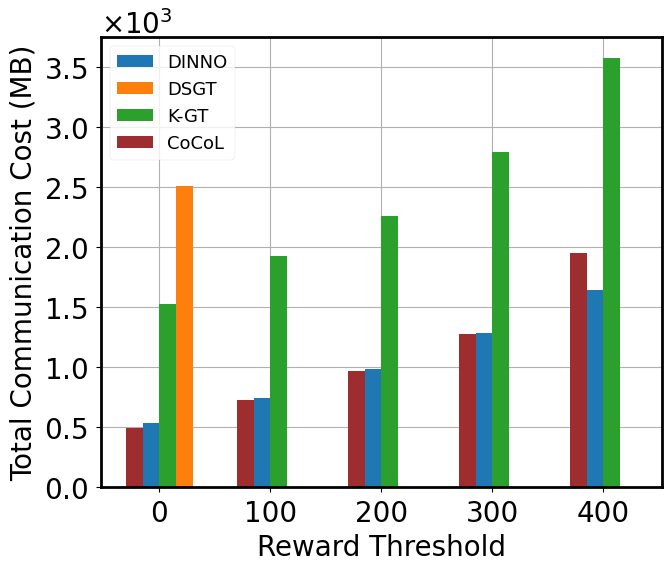

In [220]:
fig,ax1=plt.subplots(figsize=(7,6),tight_layout=True)   
model_size=0.14332962
edge=3
reward_list=np.array([0,100,200,300,400])
sonata_reward_list=[]
dinno_reward_list=[]
kgt_reward_list=[]
dsgt_reward_list=[]
for val in reward_list:
    sonata_reward=np.argmax(sonata_list>val,axis=1)*model_size*edge*2/1.1
    sonata_reward_list.append(np.mean(sonata_reward))
    dinno_reward=np.argmax(dinno_list>val,axis=1)*model_size*edge*1.2
    dinno_reward_list.append(np.mean(dinno_reward))
    kgt_reward=np.argmax(kgt_list>val,axis=1)*model_size*edge*2
    kgt_reward_list.append(np.mean(kgt_reward))
    dsgt_reward=np.argmax(dsgt_list>val,axis=1)*model_size*edge*2
    if val<100:
        dsgt_reward_list.append(np.max(dsgt_reward))
    else:
        dsgt_reward_list.append(0)
width=15
bar2=ax1.bar(reward_list-width/2,dinno_reward_list,width=width,label="DINNO")
bar4=ax1.bar(reward_list+3*width/2,dsgt_reward_list,width=width,label="DSGT")

bar3=ax1.bar(reward_list+width/2,kgt_reward_list,width=width,label="K-GT")
bar1=ax1.bar(reward_list-3*width/2,sonata_reward_list,width=width,label="CoCoL",color='#9d2d2e')

ax1.legend(loc='upper left',fontsize=13)
ax1.tick_params(axis='both', which='major', labelsize=20)
for spine in ax1.spines.values():
    spine.set_linewidth(2)  # 你可以根据需要调整这个值
ax1.grid(zorder=0)
ax1.set_axisbelow(True)  # 将轴线和网格线置于数据下方
ax1.set_xlabel('Reward Threshold',fontsize=20)
ax1.set_ylabel('Total Communication Cost (MB)',fontsize=20)
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))
ax1.yaxis.set_major_formatter(formatter)
ax1.yaxis.get_offset_text().set_fontsize(20)
# ax1.yaxis.offsetText.set_position((-0.1, 1.0))
# plt.tight_layout(pad=1.5)  # 增加边距

# fig.savefig(f'hjx_rl/t={clip}.png',dpi=300)
fig.savefig("rl_reward_threshold.pdf",dpi=800)

In [104]:
time_stamp_dis=smooth_funciton(np.load('results_sonata/timesteps_sonata_6.npy'),windows_size=window_size)
time_stamp_dis[:-100].shape

(5197,)

In [14]:
# fig.savefig("rl_reward.png",dpi=1000)
fig.savefig("rl_reward.pdf",dpi=800)


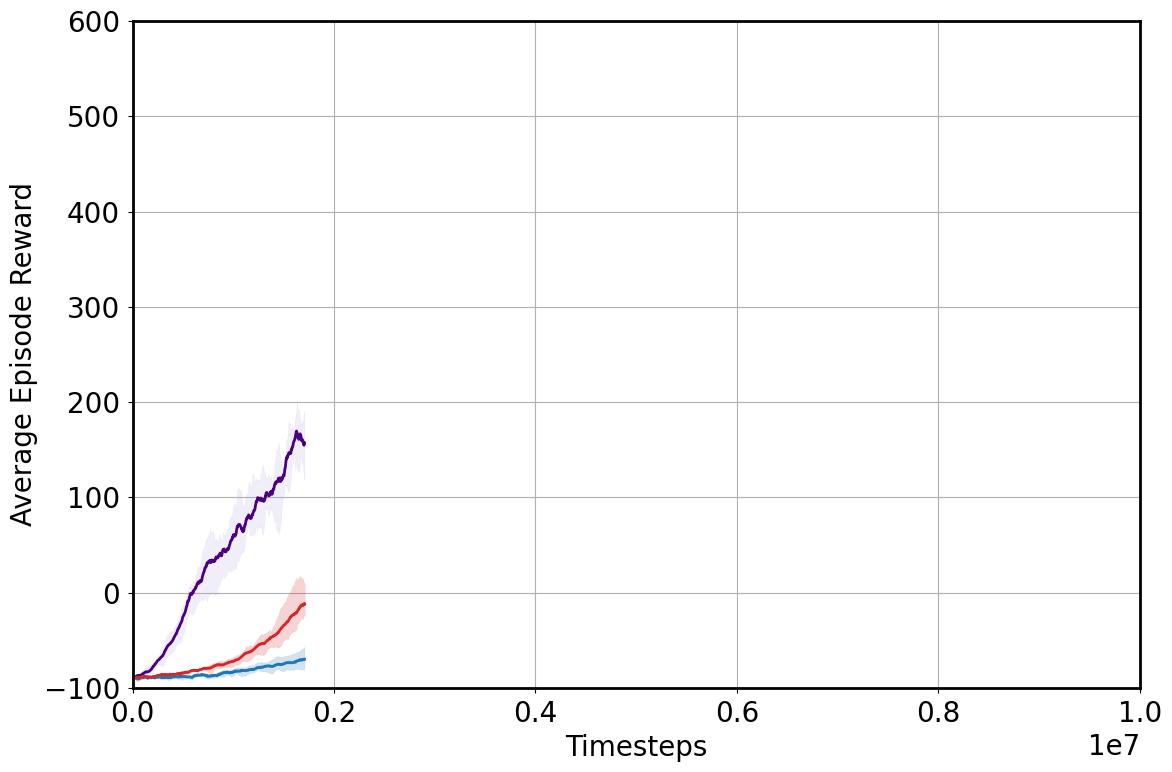

In [300]:
plt.rcParams.update({'font.size': 16})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
def smooth_funciton(data,windows_size=20):
    if windows_size==0:
        return data
    else:
        return np.convolve(data, np.ones(windows_size)/windows_size, mode='valid')
sonata_list=[]
dinno_list=[]
cen_list=[]
dsgt_list=[]
kgt_list=[]
window_size=20
(fig, ax0) = plt.subplots(figsize=(12, 8), tight_layout=True)
plt.style.use('seaborn-paper')  # 更改图表风格
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
time_stamp_dis=smooth_funciton(np.load('results_sonata/timesteps_sonata_0.npy'),windows_size=window_size)
time_stamp_dinno=smooth_funciton(np.load('results_dinno/timesteps_dinno_1.npy'),windows_size=window_size)
time_stamp_kgt=smooth_funciton(np.load('results_kgt/timesteps_kgt_0.npy'),windows_size=window_size)
time_stamp_dsgt=smooth_funciton(np.load('results_dsgt/timesteps_dsgt_0.npy'),windows_size=window_size)
time_stamp_cen=smooth_funciton(np.load('../results_cen/timesteps_0.npy'),windows_size=window_size)
for i in range(5):
    cen_reward=np.load('../results_cen/avg_ep_rews_'+str(i)+'.npy')
    cen_list.append(smooth_funciton(cen_reward,windows_size=window_size))
    sonata_reward=np.load('results_sonata/avg_ep_rews_sonata_'+str(i)+'.npy')
    sonata_list.append(smooth_funciton(sonata_reward,windows_size=window_size))
    dinno_reward=np.load('results_dinno/avg_ep_rews_dinno_'+str(i)+'.npy')
    dinno_list.append(smooth_funciton(dinno_reward,windows_size=window_size))
   
sonata_list=np.stack(sonata_list)
dinno_list=np.stack(dinno_list[1:])
cen_list=np.stack(cen_list)

clip=600
ax0.plot(time_stamp_cen[:clip],smooth(np.mean(cen_list,axis=0))[:clip],label='Centralized',c='indigo',linewidth=2)
ax0.plot(time_stamp_dinno[:clip],smooth(np.mean(dinno_list,axis=0))[:clip],label='DINNO',c=default_colors[0],linewidth=2)

ax0.plot(time_stamp_dis[:clip],smooth(np.mean(sonata_list,axis=0))[:clip],label='CoCoL',c=default_colors[3],linewidth=2)
alpha_value=0.2
ax0.fill_between(time_stamp_dinno[:clip],smooth(np.amin(dinno_list,axis=0))[:clip],smooth(np.amax(dinno_list,axis=0))[:clip],alpha=alpha_value,color=default_colors[0],zorder=6)
ax0.fill_between(time_stamp_cen[:clip],smooth(np.amin(cen_list,axis=0))[:clip],smooth(np.amax(cen_list,axis=0))[:clip],alpha=0.1,color='slateblue',zorder=1)

ax0.fill_between(time_stamp_dis[:clip],smooth(np.amin(sonata_list,axis=0))[:clip],smooth(np.amax(sonata_list,axis=0))[:clip],alpha=alpha_value,color=default_colors[3],zorder=5)

# ax0.legend(loc='lower right',fontsize=20)
ax0.tick_params(axis='both', which='major', labelsize=20)

ax0.set_xlim([0, 1e7])
ax0.set_ylim([-100, 600])
ax0.set_xlabel('Timesteps',fontsize=20)
ax0.set_ylabel('Average Episode Reward',fontsize=20)
ax0.xaxis.get_offset_text().set_fontsize(20)
# 设置边框加粗
for spine in ax0.spines.values():
    spine.set_linewidth(2)  # 你可以根据需要调整这个值
ax0.grid()
# fig.savefig(f'hjx_rl/t={clip}.png',dpi=300)

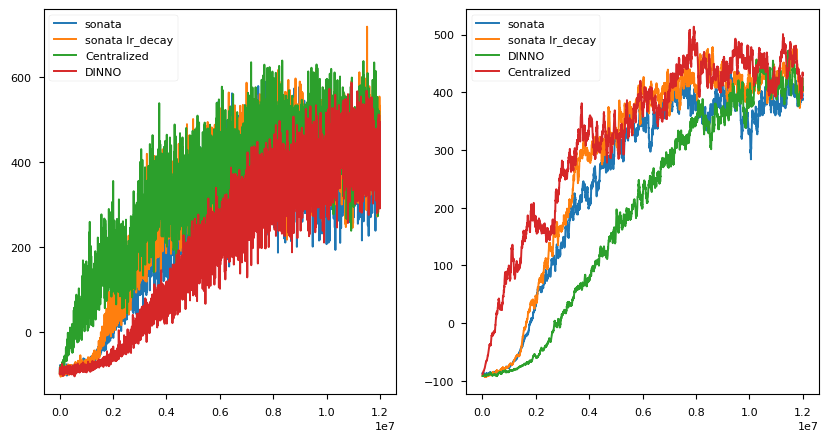

In [164]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
times=np.load('results_sonata/timesteps_sonata_300.npy')
clip_time=times[:np.argwhere(times>1.2e7)[0][0]]
timeLen=clip_time.shape[0]
reward_cent1=np.load('../trained/avg_ep_rews.npy')

rewards_d1 = np.load('results_rl/avg_ep_rews_dinno_100.npy')
rewards_s3=np.load('results_sonata/avg_ep_rews_sonata_300.npy')
rewards_s5=np.load('results_sonata/avg_ep_rews_sonata_500.npy')
# rewards_clip=rewards_s5

ax[0].plot(clip_time,rewards_s3[:timeLen],label='sonata')
ax[0].plot(clip_time,rewards_s5[:timeLen],label='sonata lr_decay')
ax[0].plot(clip_time,reward_cent1[:timeLen],label='Centralized')
ax[0].plot(clip_time,rewards_d1[:timeLen],label='DINNO')
#plot moving average
window=20

rewards_s3_ma=np.convolve(rewards_s3, np.ones(window), 'valid') / window
rewards_s5_ma=np.convolve(rewards_s5, np.ones(window), 'valid') / window
rewards_d1_ma=np.convolve(rewards_d1, np.ones(window), 'valid') / window
reward_cent1_ma=np.convolve(reward_cent1, np.ones(window), 'valid') / window

ax[1].plot(clip_time,rewards_s3_ma[:timeLen],label='sonata')
ax[1].plot(clip_time,rewards_s5_ma[:timeLen],label='sonata lr_decay')
ax[1].plot(clip_time,rewards_d1_ma[:timeLen],label='DINNO')
ax[1].plot(clip_time,reward_cent1_ma[:timeLen],label='Centralized')
ax[0].legend()
ax[1].legend()